In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pulsed_tools import *

Helper functions are defined and ready to use.


In [6]:

channel_map = {
    'Pulse_1': 1,
    'Pulse_2': 2,
    'Trigger': 5,      # Available but not used in this sequence
    'Microwave': 7,    # Available but not used in this sequence
}

wait_time_sweep = {
    'start': 60,    # Start with a 1 µs wait
    'end': 60,    # End with a 200 µs wait
    'steps': 50,  # Perform 50 steps as requested
}

PULSE_1_DURATION_US = 60
PULSE_2_DURATION_US = 0

POST_PULSE_WAIT_US = 100
TRIGGER_DURATION_US: float = 0.05 # Duration for the trigger pulse, if used



--- Creating sweep sequence with 50 steps ---
Total continuous sequence duration: 18002.50 µs
--- Generating Plot: Time Delay Sweep (First 3 Steps) ---


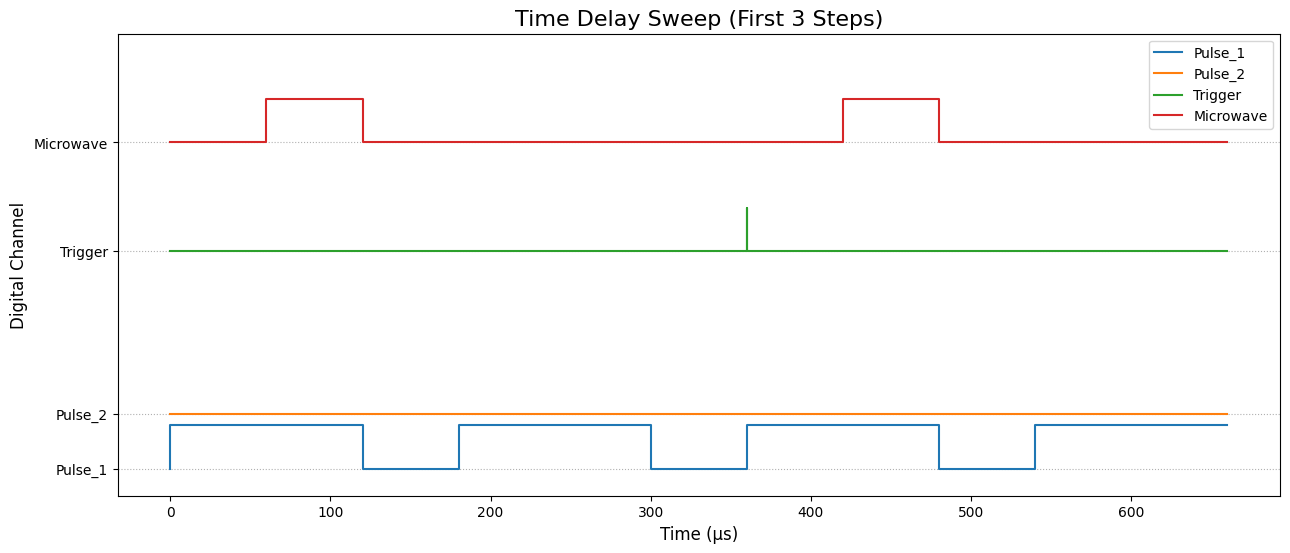

In [7]:

def time_delay_subsequence_generator(swept_wait_time_us):
    """
    Generates the sequence: [100µs Pulse] -> [Swept Wait] -> [50µs Pulse] -> [Fixed Wait]
    """
    sub_sequence = [
        # Part 1: The starting 100 µs pulse
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['Pulse_1']},
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['Pulse_1', "Microwave"]},
        # Part 2: The variable waiting time, passed in as an argument
        {'duration_us': swept_wait_time_us, 'channels_on': []},
        
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['Pulse_1']},
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['Pulse_1']},
         {'duration_us': PULSE_1_DURATION_US, 'channels_on': []},
        
        # Part 3: The second 50 µs pulse
       
        # Part 4: A fixed wait/readout time before the next sequence starts
       
        {'duration_us': TRIGGER_DURATION_US, 'channels_on': ['Trigger']},
        
         

    ]
    return sub_sequence

full_sweep_sequence, total_duration = create_sweep_sequence(
    wait_time_sweep,
    time_delay_subsequence_generator,
    channel_map
)

one_step_duration = PULSE_1_DURATION_US + wait_time_sweep['start'] + PULSE_2_DURATION_US + POST_PULSE_WAIT_US
plot_window = one_step_duration * 3 # Plot the first 3 cycles

plot_sequence(
    full_sweep_sequence,
    channel_map,
    plot_duration_us=plot_window,
    title="Time Delay Sweep (First 3 Steps)"
)

In [ ]:
print("Uploading sequence with trigger and repump to the Pulse Streamer...")

pulsestreamer.upload_sequence(full_sweep_sequence)

print("Starting the pulse sequence...")

pulsestreamer.ps.stream(pulsestreamer.sequence_data, n_runs=-1)


Uploading sequence with trigger and repump to the Pulse Streamer...
Starting the pulse sequence...
